In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Using device: cuda

--- Running FGSM for Pedestrian Classifier ---
Successfully loaded model from /content/drive/MyDrive/ML_Safety/models/pedestrian_resnet18.pth


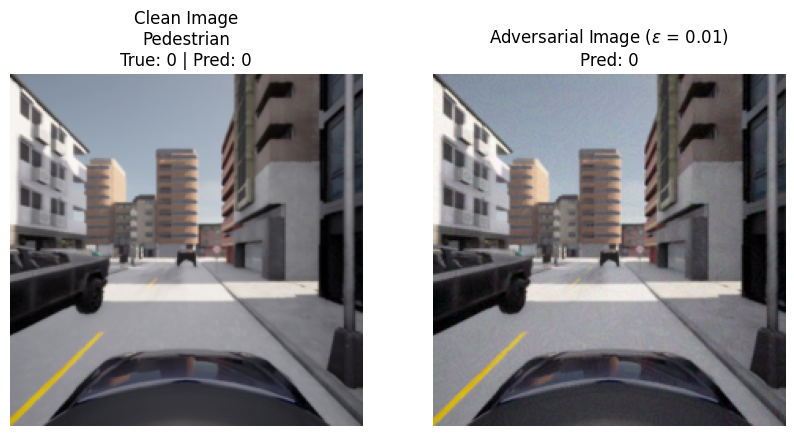

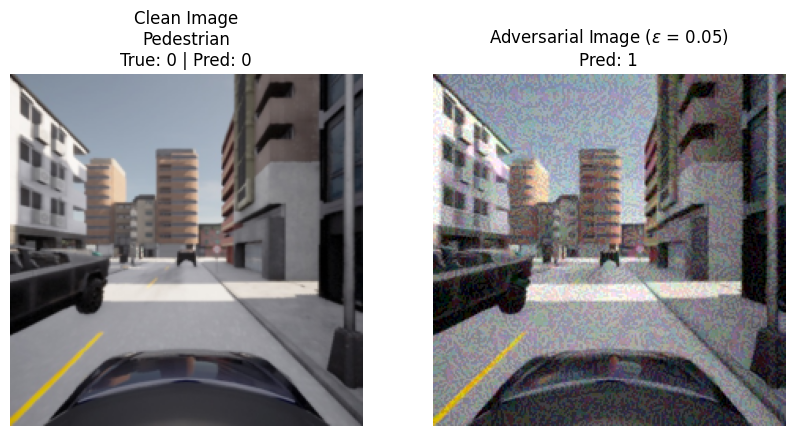

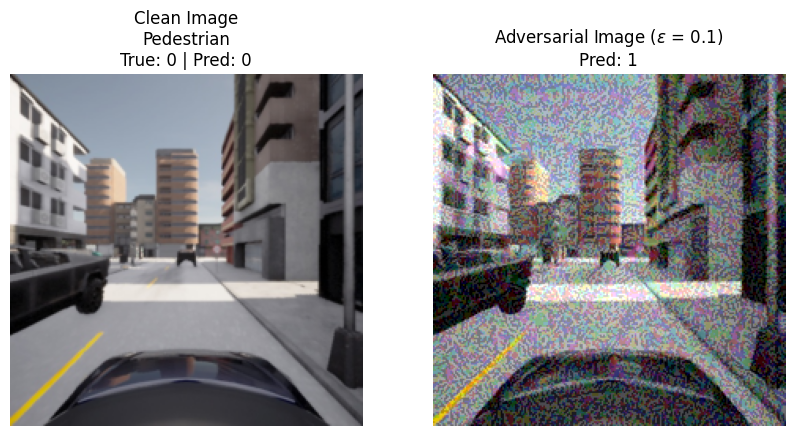


--- Running FGSM for Traffic Light Classifier ---
Successfully loaded model from /content/drive/MyDrive/ML_Safety/models/traffic_light_resnet18.pth


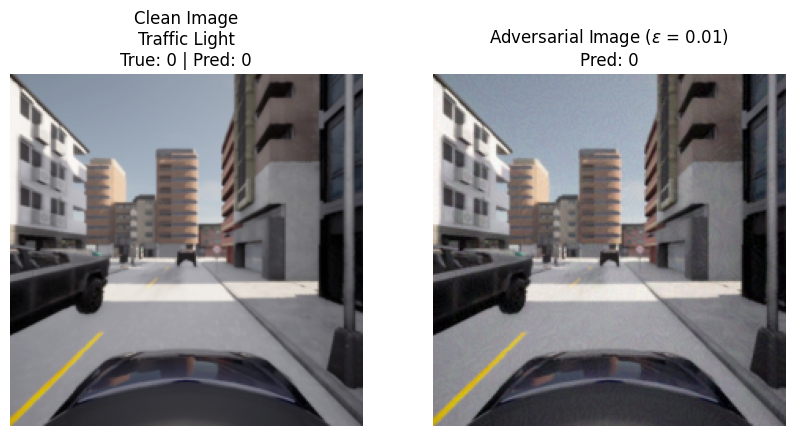

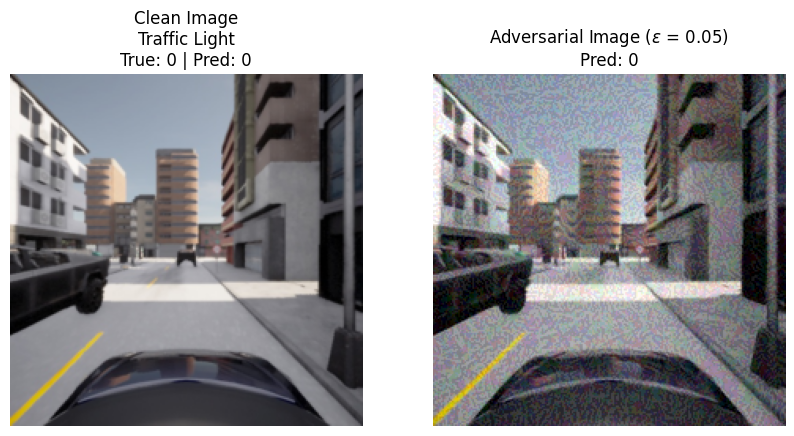

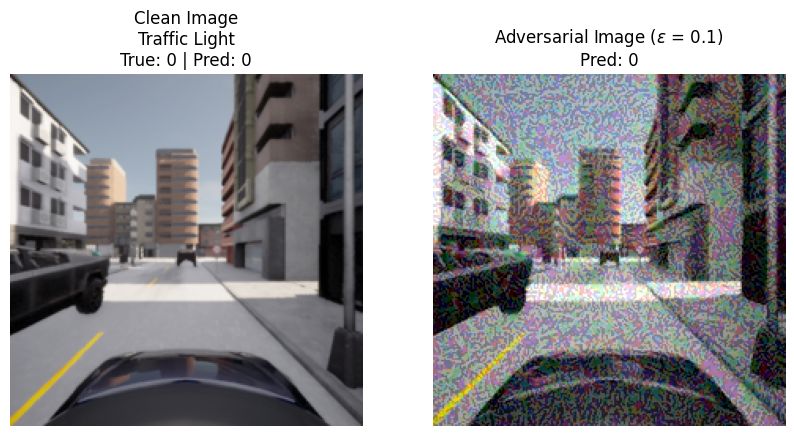


--- Running FGSM for Vehicle Classifier ---
Successfully loaded model from /content/drive/MyDrive/ML_Safety/models/vehicle_resnet18.pth


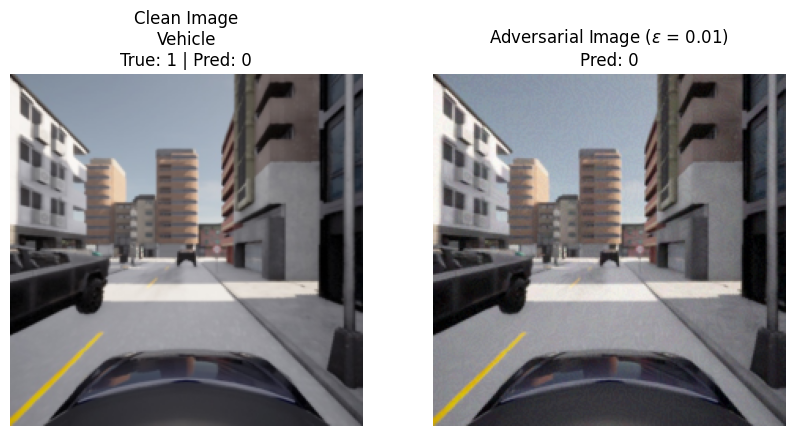

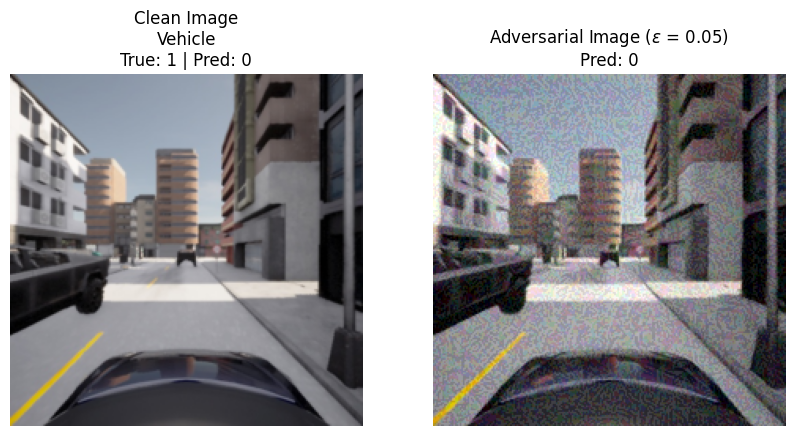

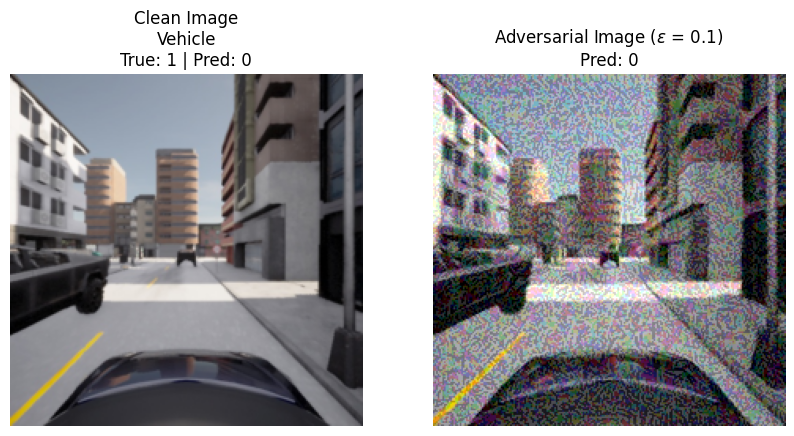

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os

# --- 1. Custom Dataset for CARLA ---
class CARLA_Dataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.labels_df = pd.read_csv(os.path.join(data_dir, 'labels.csv'))
        self.transform = transform

        # Ensure frame is string padded with zeros
        self.labels_df['frame'] = self.labels_df['frame'].astype(str).str.zfill(6)

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        frame = row['frame']

        # Load image
        img_path = os.path.join(self.data_dir, 'rgb-front', f"{frame}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # For single output BCE loss, targets need to be floats with shape [1]
        targets = {
            'Traffic Light': torch.tensor([float(row['has_traffic_light'])], dtype=torch.float),
            'Pedestrian': torch.tensor([float(row['has_pedestrian'])], dtype=torch.float),
            'Vehicle': torch.tensor([float(row['has_vehicle'])], dtype=torch.float)
        }

        return image, targets

# --- 2. FGSM Implementation ---
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

def imshow_side_by_side(orig, perturbed, epsilon, task_name, true_label, init_pred, final_pred):
    orig_np = orig.squeeze().detach().cpu().numpy().transpose((1, 2, 0))
    perturbed_np = perturbed.squeeze().detach().cpu().numpy().transpose((1, 2, 0))

    orig_np = np.clip(orig_np, 0, 1)
    perturbed_np = np.clip(perturbed_np, 0, 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(orig_np)
    # Added 'r' prefix to make it a raw string, fixing the syntax warning
    ax1.set_title(f'Clean Image\n{task_name}\nTrue: {int(true_label.item())} | Pred: {init_pred}')
    ax1.axis('off')

    ax2.imshow(perturbed_np)
    ax2.set_title(fr'Adversarial Image ($\epsilon$ = {epsilon})' + f'\nPred: {final_pred}')
    ax2.axis('off')

    plt.show()

def get_binary_resnet18(model_path, device):
    # Fixed deprecation warnings
    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    # FIXED: Changed from 2 to 1 to match your saved weight dimensions
    model.fc = nn.Linear(num_ftrs, 1)

    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
        print(f"Successfully loaded model from {model_path}")
    else:
        print(f"Warning: Model file not found at {model_path}. Using untrained weights.")

    model.to(device)
    model.eval()
    return model

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    test_data_dir = '/content/drive/MyDrive/ML_Safety/test'

    dataset = CARLA_Dataset(test_data_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

    models_dict = {
        'Pedestrian': '/content/drive/MyDrive/ML_Safety/models/pedestrian_resnet18.pth',
        'Traffic Light': '/content/drive/MyDrive/ML_Safety/models/traffic_light_resnet18.pth',
        'Vehicle': '/content/drive/MyDrive/ML_Safety/models/vehicle_resnet18.pth'
    }

    epsilons = [0.01, 0.05, 0.1]
    # FIXED: Changed from CrossEntropyLoss to BCEWithLogitsLoss for 1-feature outputs
    criterion = nn.BCEWithLogitsLoss()

    # Get one batch (1 image) for the demonstration
    data, targets = next(iter(dataloader))
    data = data.to(device)

    for task_name, model_path in models_dict.items():
        print(f"\n{'='*50}\n--- Running FGSM for {task_name} Classifier ---\n{'='*50}")
        model = get_binary_resnet18(model_path, device)
        target = targets[task_name].to(device)

        # Create a fresh copy of data for each model's gradient computation
        input_data = data.clone().detach().to(device)
        input_data.requires_grad = True

        output = model(input_data)

        # FIXED: With 1 output logit, a value > 0 means class 1, <= 0 means class 0
        init_pred = 1 if output.item() > 0 else 0

        loss = criterion(output, target)
        model.zero_grad()
        loss.backward()

        data_grad = input_data.grad.data.clone()

        for eps in epsilons:
            perturbed_data = fgsm_attack(input_data.detach(), eps, data_grad)

            # Re-classify the perturbed image
            adv_output = model(perturbed_data)
            final_pred = 1 if adv_output.item() > 0 else 0

            imshow_side_by_side(input_data, perturbed_data, eps, task_name, target, init_pred, final_pred)

if __name__ == '__main__':
    main()

In [ ]:
print('hi')

hi


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, Subset
import pandas as pd
from PIL import Image
import os
import random

# --- 1. Custom Dataset for CARLA ---
class CARLA_Dataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.labels_df = pd.read_csv(os.path.join(data_dir, 'labels.csv'))
        self.transform = transform

        # Ensure frame is string padded with zeros
        self.labels_df['frame'] = self.labels_df['frame'].astype(str).str.zfill(6)

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        frame = row['frame']

        # Load image
        img_path = os.path.join(self.data_dir, 'rgb-front', f"{frame}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # For single output BCE loss, targets need to be floats with shape [1]
        targets = {
            'Traffic Light': torch.tensor([float(row['has_traffic_light'])], dtype=torch.float),
            'Pedestrian': torch.tensor([float(row['has_pedestrian'])], dtype=torch.float),
            'Vehicle': torch.tensor([float(row['has_vehicle'])], dtype=torch.float)
        }

        return image, targets

# --- 2. FGSM Implementation ---
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

def get_binary_resnet18(model_path, device):
    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    # FIXED: Changed from 2 to 1 to match your saved weight dimensions
    model.fc = nn.Linear(num_ftrs, 1)

    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    else:
        print(f"Warning: Model file not found at {model_path}. Using untrained weights.")

    model.to(device)
    model.eval()
    return model

def calculate_metrics(y_true, y_pred):
    """
    Calculates the recall metric: TP / (TP + FN)
    """
    tp = sum(1 for true, pred in zip(y_true, y_pred) if true == 1 and pred == 1)
    fn = sum(1 for true, pred in zip(y_true, y_pred) if true == 1 and pred == 0)

    # Avoid division by zero
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return recall

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    # Update to your Colab Path
    test_data_dir = '/content/drive/MyDrive/ML_Safety/test'

    full_dataset = CARLA_Dataset(test_data_dir, transform=transform)

    # Subsampling 100 images randomly to save time
    # We set a seed so the subset is reproducible across runs
    torch.manual_seed(42)
    random.seed(42)
    indices = random.sample(range(len(full_dataset)), min(100, len(full_dataset)))
    dataset = Subset(full_dataset, indices)

    # Batch size of 1 to run gradient extraction sequentially per image
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    models_dict = {
        'Pedestrian': '/content/drive/MyDrive/ML_Safety/models/pedestrian_resnet18.pth',
        'Traffic Light': '/content/drive/MyDrive/ML_Safety/models/traffic_light_resnet18.pth',
        'Vehicle': '/content/drive/MyDrive/ML_Safety/models/vehicle_resnet18.pth'
    }

    epsilons = [0.01, 0.05, 0.1]
    criterion = nn.BCEWithLogitsLoss()

    for task_name, model_path in models_dict.items():
        print(f"\n{'='*50}\n--- Evaluating Robustness for {task_name} Classifier ---\n{'='*50}")
        model = get_binary_resnet18(model_path, device)

        y_true = []
        y_pred_clean = []
        y_pred_adv = {eps: [] for eps in epsilons}

        # Iterate over the 100 sampled images
        for data, targets in dataloader:
            data = data.to(device)
            target = targets[task_name].to(device)

            # Record true label
            y_true.append(int(target.item()))

            # --- Clean Image Evaluation ---
            input_data = data.clone().detach().to(device)
            input_data.requires_grad = True

            output = model(input_data)
            pred_clean = 1 if output.item() > 0 else 0
            y_pred_clean.append(pred_clean)

            # Calculate gradient for FGSM
            loss = criterion(output, target)
            model.zero_grad()
            loss.backward()

            data_grad = input_data.grad.data.clone()

            # --- Adversarial Image Evaluation ---
            for eps in epsilons:
                perturbed_data = fgsm_attack(input_data.detach(), eps, data_grad)

                adv_output = model(perturbed_data)
                pred_adv = 1 if adv_output.item() > 0 else 0
                y_pred_adv[eps].append(pred_adv)

        # Calculate and report recall
        recall_clean = calculate_metrics(y_true, y_pred_clean)
        print(f"Clean Recall: {recall_clean:.4f}")

        for eps in epsilons:
            recall_adv = calculate_metrics(y_true, y_pred_adv[eps])
            drop = recall_clean - recall_adv
            print(f"Epsilon {eps} -> Adversarial Recall: {recall_adv:.4f} (Recall Drop: {drop:.4f})")

if __name__ == '__main__':
    main()


Using device: cuda

--- Evaluating Robustness for Pedestrian Classifier ---
Clean Recall: 0.0435
Epsilon 0.01 -> Adversarial Recall: 0.0000 (Recall Drop: 0.0435)
Epsilon 0.05 -> Adversarial Recall: 0.0000 (Recall Drop: 0.0435)
Epsilon 0.1 -> Adversarial Recall: 0.0000 (Recall Drop: 0.0435)

--- Evaluating Robustness for Traffic Light Classifier ---
Clean Recall: 0.2817
Epsilon 0.01 -> Adversarial Recall: 0.0000 (Recall Drop: 0.2817)
Epsilon 0.05 -> Adversarial Recall: 0.0000 (Recall Drop: 0.2817)
Epsilon 0.1 -> Adversarial Recall: 0.0000 (Recall Drop: 0.2817)

--- Evaluating Robustness for Vehicle Classifier ---
Clean Recall: 0.1250
Epsilon 0.01 -> Adversarial Recall: 0.0000 (Recall Drop: 0.1250)
Epsilon 0.05 -> Adversarial Recall: 0.0000 (Recall Drop: 0.1250)
Epsilon 0.1 -> Adversarial Recall: 0.0000 (Recall Drop: 0.1250)


In [ ]:
print('hi')

hi
